<a href="https://colab.research.google.com/github/crodriguezbay/MLforMkting/blob/main/Cuaderno_de_trabajo_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este cuaderno es un compendio de algunas de las intruccciones que más vamos a usar en python durante el curso. Te invito a desarrollarlas siguiendo las instrucciones en clase, pidiendole explicaciones a gemini (u otro LLM) y pidiendo también a tu LLM con el que te sientas más comodo que te ayude a realizarlas:

1 Busca en kaggle.com los datasets Mall Customer Segmentation Data y Customer Personality Analysis y cargalos en dos dataframes diferentes. Aprenderás la función pd.read_csv. Nota que el archivo de Customer Personality Analysis está separado por "\t". Debes cargar los archivos csv de cada dataset en la carpeta /content/sample_data del google colab.

*   Carga los archivos al ambiente de google colab.
*   Carga la libreria pandas (pd)
*   Carga los archivos en dataframes diferentes.





In [ ]:
import pandas as pd
df_MCSD = pd.read_csv('/content/sample_data/Mall_Customers.csv')
display(df_MCSD.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:

df_CPA = pd.read_csv('/content/sample_data/marketing_campaign.csv', sep= '\t')
display(df_CPA.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


2. Describe los dataframe:

*   Número de filas y columnas
*   Nombres de las columnas
*   Tipos de datos de cada columna, valores nulos






### Descripción de `df_MCSD`

In [ ]:
print('--- Información General de df_MCSD ---')
print(f"Número de filas y columnas: {df_MCSD.shape}")
print(f"Nombres de las columnas: {df_MCSD.columns.tolist()}")
print('\nTipos de datos y valores no nulos:')
df_MCSD.info()
print('\nValores nulos por columna:')
print(df_MCSD.isnull().sum())

--- Información General de df_MCSD ---
Número de filas y columnas: (200, 5)
Nombres de las columnas: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### Descripción de `df_CPA`

In [ ]:
print('\n--- Información General de df_CPA ---')
print(f"Número de filas y columnas: {df_CPA.shape}")
print(f"Nombres de las columnas: {df_CPA.columns.tolist()}")
print('\nTipos de datos y valores no nulos:')
df_CPA.info()
print('\nValores nulos por columna:')
print(df_CPA.isnull().sum())


--- Información General de df_CPA ---
Número de filas y columnas: (2240, 29)
Nombres de las columnas: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   

3. Crea una función que permita ver histogramas de cada uno de las columnas numéricas de un dataframe y usalos con los dataframes que se están revisando:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(df, title_prefix="Histograms for"):
    """Plots histograms for all numerical columns in a DataFrame."""
    print(f'\n--- {title_prefix} {df.name if hasattr(df, "name") else "DataFrame"} ---')
    numerical_cols = df.select_dtypes(include=['number']).columns

    if numerical_cols.empty:
        print("No numerical columns found to plot histograms.")
        return

    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3 # Roughly 3 plots per row

    plt.figure(figsize=(15, 5 * n_rows))
    plt.suptitle(f'{title_prefix} {df.name if hasattr(df, "name") else "DataFrame"}', fontsize=16)

    for i, col in enumerate(numerical_cols):
        plt.subplot(n_rows, 3, i + 1)
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()



--- Histograms for Mall Customer Segmentation Data ---


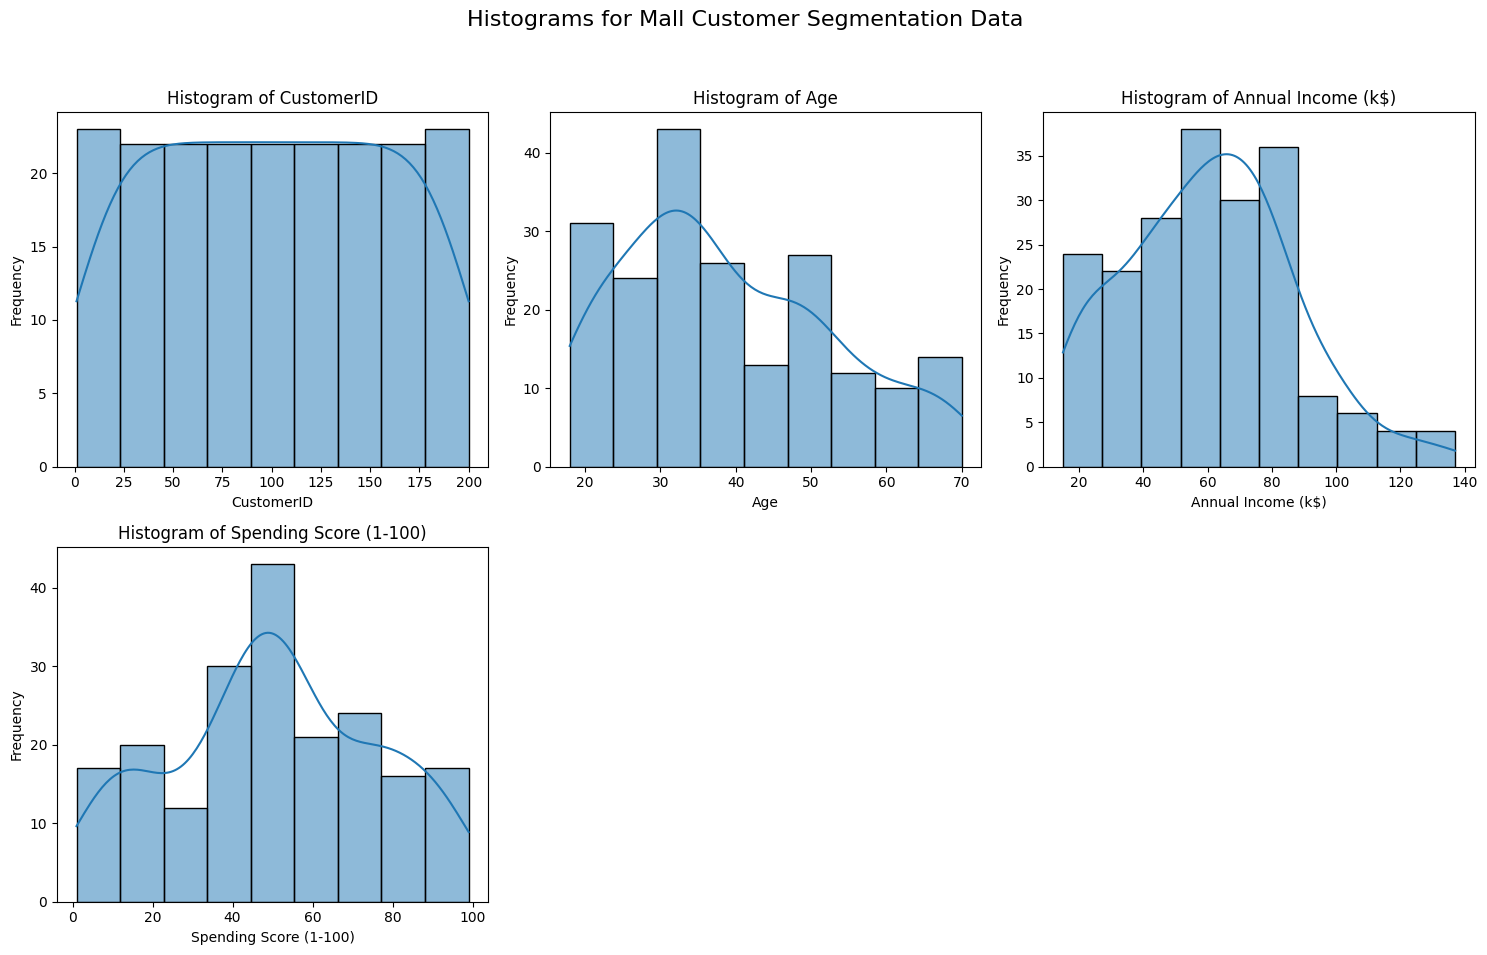


--- Histograms for Customer Personality Analysis ---


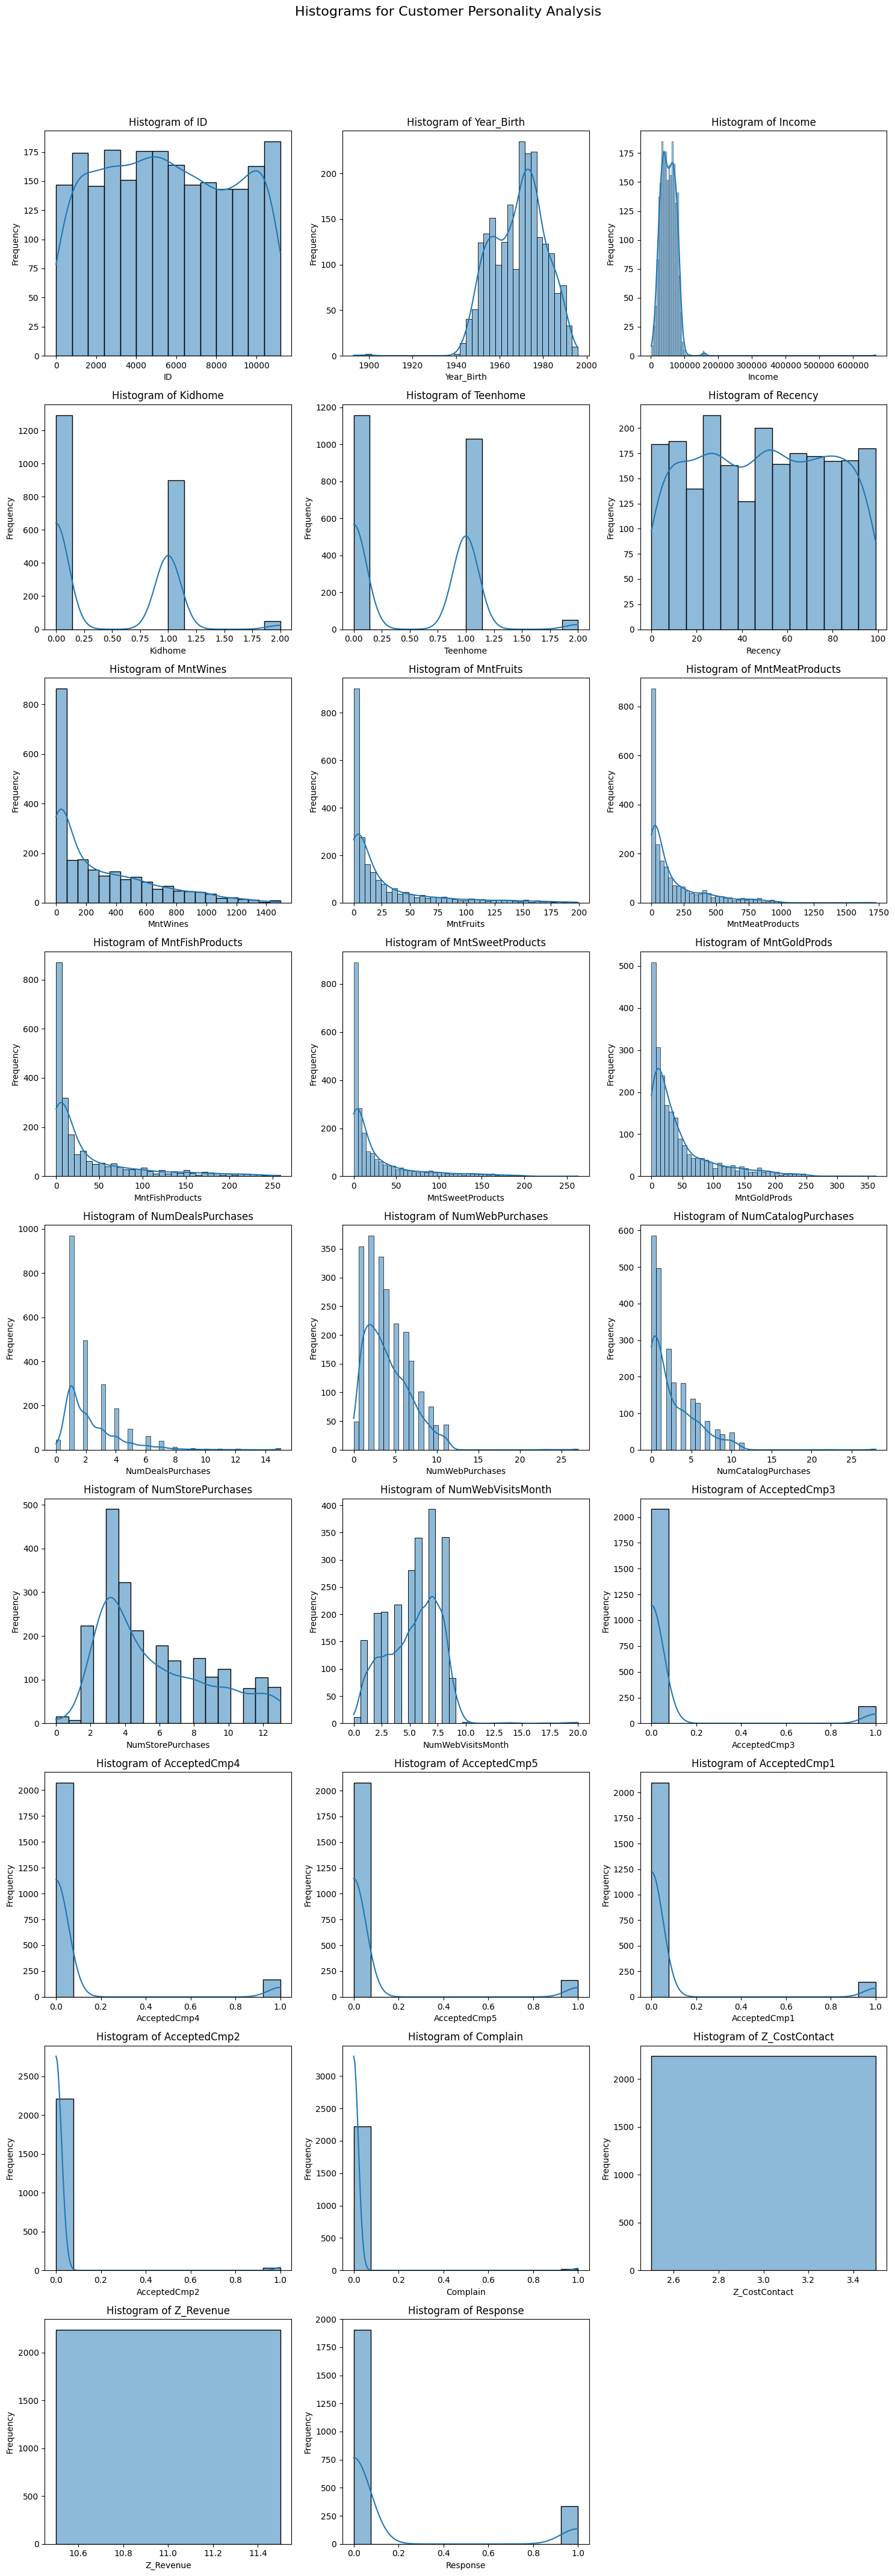

In [ ]:
# Asignar nombres a los DataFrames para una mejor visualización en la función
df_MCSD.name = 'Mall Customer Segmentation Data'
df_CPA.name = 'Customer Personality Analysis'

# Usar la función con df_MCSD
plot_histograms(df_MCSD)

# Usar la función con df_CPA
plot_histograms(df_CPA)

4. Crea una función que permita ver histogramas de variables categóricas que un dataframe, ingresandole los nombres de las variables categóricas que se quieren graficar:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_histograms(df, categorical_cols, title_prefix="Categorical Histograms for"):
    """Plots histograms (bar plots) for specified categorical columns in a DataFrame."""
    print(f'\n--- {title_prefix} {df.name if hasattr(df, "name") else "DataFrame"} ---')

    if not categorical_cols:
        print("No categorical columns specified to plot.")
        return

    # Filter to only include columns that are actually in the DataFrame
    existing_categorical_cols = [col for col in categorical_cols if col in df.columns]

    if not existing_categorical_cols:
        print("None of the specified categorical columns were found in the DataFrame.")
        return

    n_cols = len(existing_categorical_cols)
    n_rows = (n_cols + 2) // 3  # Roughly 3 plots per row

    plt.figure(figsize=(15, 5 * n_rows))
    plt.suptitle(f'{title_prefix} {df.name if hasattr(df, "name") else "DataFrame"}', fontsize=16)

    for i, col in enumerate(existing_categorical_cols):
        plt.subplot(n_rows, 3, i + 1)
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Generando histogramas para df_MCSD...

--- Categorical Histograms for Mall Customer Segmentation Data ---


/tmp/ipykernel_2580/443505629.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


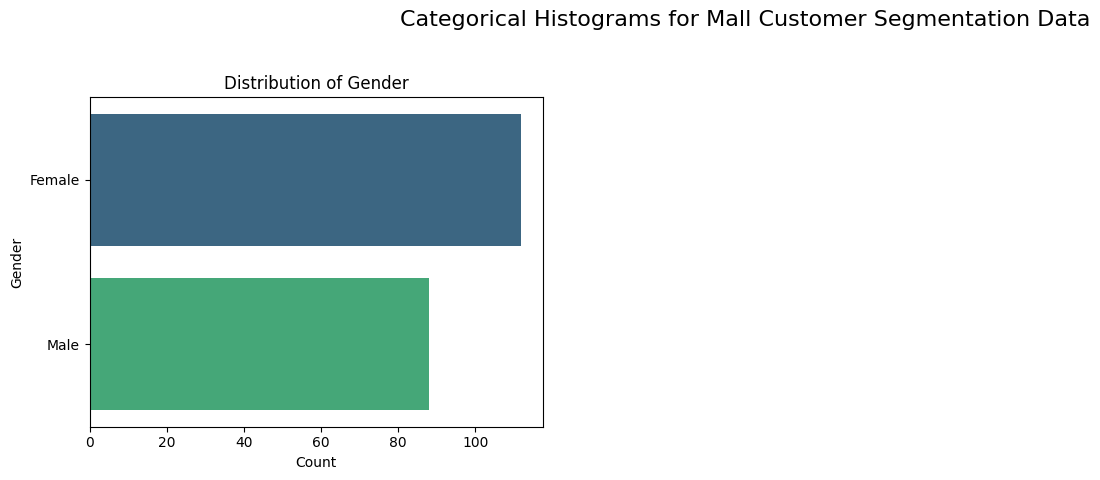


Generando histogramas para df_CPA...

--- Categorical Histograms for Customer Personality Analysis ---


/tmp/ipykernel_2580/443505629.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_2580/443505629.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


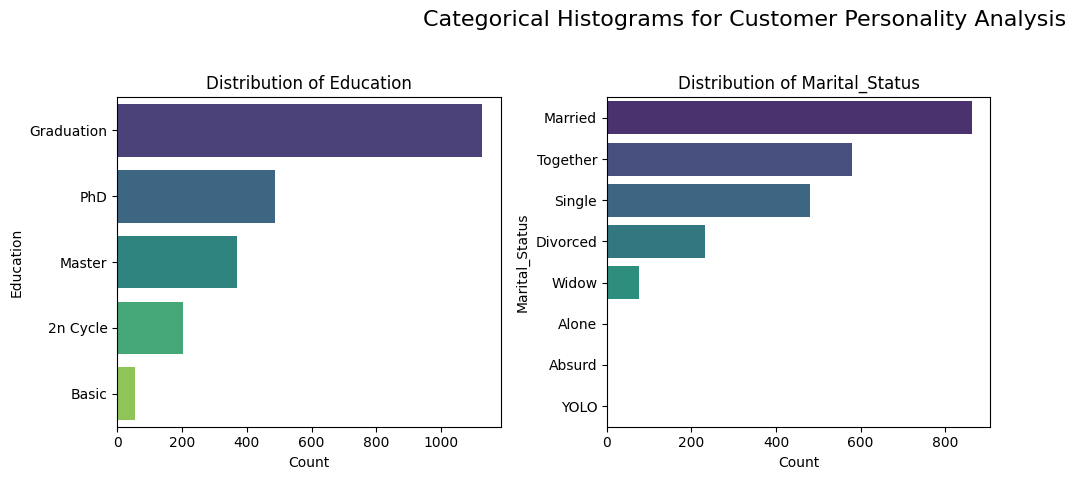

In [ ]:
# Usar la función con df_MCSD
print('Generando histogramas para df_MCSD...')
plot_categorical_histograms(df_MCSD, ['Gender'])

# Usar la función con df_CPA
print('\nGenerando histogramas para df_CPA...')
plot_categorical_histograms(df_CPA, ['Education', 'Marital_Status'])

5. Crea una función que construya una tabla con las estadísticas descriptivas principales de cada columna numérica en un data frame: media, mediana, percentil 25, percentil 50, percentil 75, desviación estándar, coeficiente de variación.


In [ ]:
import numpy as np

def descriptive_stats_table(df):
    """Calculates a table with main descriptive statistics for numerical columns."""
    print(f'\n--- Descriptive Statistics for {df.name if hasattr(df, "name") else "DataFrame"} ---')
    numerical_cols = df.select_dtypes(include=['number'])

    if numerical_cols.empty:
        print("No numerical columns found in the DataFrame.")
        return pd.DataFrame()

    stats_dict = {
        'mean': numerical_cols.mean(),
        'median': numerical_cols.median(),
        '25th_percentile': numerical_cols.quantile(0.25),
        '50th_percentile': numerical_cols.quantile(0.50), # Same as median
        '75th_percentile': numerical_cols.quantile(0.75),
        'std_dev': numerical_cols.std()
    }

    stats_df = pd.DataFrame(stats_dict)

    # Calculate Coefficient of Variation (CV = std / mean)
    # Handle cases where mean might be zero to avoid division by zero
    stats_df['coeff_of_variation'] = np.where(
        stats_df['mean'] == 0, # Condition
        np.nan,               # Value if True (e.g., CV is undefined or infinite)
        stats_df['std_dev'] / stats_df['mean'] # Value if False
    )

    return stats_df

Ahora, vamos a usar esta función con nuestros dataframes `df_MCSD` y `df_CPA`:

In [ ]:
# Usar la función con df_MCSD
display(descriptive_stats_table(df_MCSD))

# Usar la función con df_CPA
display(descriptive_stats_table(df_CPA))


--- Descriptive Statistics for Mall Customer Segmentation Data ---


,mean,median,25th_percentile,50th_percentile,75th_percentile,std_dev,coeff_of_variation
CustomerID,100.50,100.5,50.75,100.5,150.25,57.879185,0.575912
Age,38.85,36.0,28.75,36.0,49.00,13.969007,0.359563
Annual Income (k$),60.56,61.5,41.50,61.5,78.00,26.264721,0.433698
Spending Score (1-100),50.20,50.0,34.75,50.0,73.00,25.823522,0.514413



--- Descriptive Statistics for Customer Personality Analysis ---


,mean,median,25th_percentile,50th_percentile,75th_percentile,std_dev,coeff_of_variation
ID,5592.159821,5458.5,2828.25,5458.5,8427.75,3246.662198,0.580574
Year_Birth,1968.805804,1970.0,1959.00,1970.0,1977.00,11.984069,0.006087
Income,52247.251354,51381.5,35303.00,51381.5,68522.00,25173.076661,0.481807
Kidhome,0.444196,0.0,0.00,0.0,1.00,0.538398,1.212072
Teenhome,0.506250,0.0,0.00,0.0,1.00,0.544538,1.075631
Recency,49.109375,49.0,24.00,49.0,74.00,28.962453,0.589754
MntWines,303.935714,173.5,23.75,173.5,504.25,336.597393,1.107462
MntFruits,26.302232,8.0,1.00,8.0,33.00,39.773434,1.512170
MntMeatProducts,166.950000,67.0,16.00,67.0,232.00,225.715373,1.351994
MntFishProducts,37.525446,12.0,3.00,12.0,50.00,54.628979,1.455785


6. Imputa valores nulos en la colina income de CPA con el promedio.

### Manejo de Valores Nulos en `df_CPA` (Columna 'Income')

In [ ]:
# Imputar los valores nulos en la columna 'Income' con la media
df_CPA['Income'].fillna(df_CPA['Income'].mean(), inplace=True)

print('Valores nulos en df_CPA después de la imputación:')
print(df_CPA.isnull().sum()['Income'])

# Opcional: Volver a mostrar las estadísticas descriptivas para ver el impacto
display(descriptive_stats_table(df_CPA))

Valores nulos en df_CPA después de la imputación:
0

--- Descriptive Statistics for Customer Personality Analysis ---


/tmp/ipykernel_2580/675268753.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_CPA['Income'].fillna(df_CPA['Income'].mean(), inplace=True)


,mean,median,25th_percentile,50th_percentile,75th_percentile,std_dev,coeff_of_variation
ID,5592.159821,5458.5,2828.25,5458.5,8427.75,3246.662198,0.580574
Year_Birth,1968.805804,1970.0,1959.00,1970.0,1977.00,11.984069,0.006087
Income,52247.251354,51741.5,35538.75,51741.5,68289.75,25037.797168,0.479217
Kidhome,0.444196,0.0,0.00,0.0,1.00,0.538398,1.212072
Teenhome,0.506250,0.0,0.00,0.0,1.00,0.544538,1.075631
Recency,49.109375,49.0,24.00,49.0,74.00,28.962453,0.589754
MntWines,303.935714,173.5,23.75,173.5,504.25,336.597393,1.107462
MntFruits,26.302232,8.0,1.00,8.0,33.00,39.773434,1.512170
MntMeatProducts,166.950000,67.0,16.00,67.0,232.00,225.715373,1.351994
MntFishProducts,37.525446,12.0,3.00,12.0,50.00,54.628979,1.455785


7. Convierte las columnas ID de Df_CPA y CustomerID de df_MCSD en los indices de los dataframes:

In [ ]:
# Convertir 'ID' en el índice de df_CPA
df_CPA.set_index('ID', inplace=True)

# Convertir 'CustomerID' en el índice de df_MCSD
df_MCSD.set_index('CustomerID', inplace=True)

print('Primeras 5 filas de df_CPA con ID como índice:')
display(df_CPA.head())

print('\nPrimeras 5 filas de df_MCSD con CustomerID como índice:')
display(df_MCSD.head())

Primeras 5 filas de df_CPA con ID como índice:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0



Primeras 5 filas de df_MCSD con CustomerID como índice:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


8. Genera de nuevo las tablas de estadísticas descriptivas:

In [ ]:
# Usar la función con df_MCSD
display(descriptive_stats_table(df_MCSD))

# Usar la función con df_CPA
display(descriptive_stats_table(df_CPA))


--- Descriptive Statistics for Mall Customer Segmentation Data ---


,mean,median,25th_percentile,50th_percentile,75th_percentile,std_dev,coeff_of_variation
Age,38.85,36.0,28.75,36.0,49.0,13.969007,0.359563
Annual Income (k$),60.56,61.5,41.50,61.5,78.0,26.264721,0.433698
Spending Score (1-100),50.20,50.0,34.75,50.0,73.0,25.823522,0.514413



--- Descriptive Statistics for Customer Personality Analysis ---


,mean,median,25th_percentile,50th_percentile,75th_percentile,std_dev,coeff_of_variation
Year_Birth,1968.805804,1970.0,1959.00,1970.0,1977.00,11.984069,0.006087
Income,52247.251354,51741.5,35538.75,51741.5,68289.75,25037.797168,0.479217
Kidhome,0.444196,0.0,0.00,0.0,1.00,0.538398,1.212072
Teenhome,0.506250,0.0,0.00,0.0,1.00,0.544538,1.075631
Recency,49.109375,49.0,24.00,49.0,74.00,28.962453,0.589754
MntWines,303.935714,173.5,23.75,173.5,504.25,336.597393,1.107462
MntFruits,26.302232,8.0,1.00,8.0,33.00,39.773434,1.512170
MntMeatProducts,166.950000,67.0,16.00,67.0,232.00,225.715373,1.351994
MntFishProducts,37.525446,12.0,3.00,12.0,50.00,54.628979,1.455785
MntSweetProducts,27.062946,8.0,1.00,8.0,33.00,41.280498,1.525351


9. Convierte la columna Dt_Customer de df_CPA en un formato de fecha:

In [ ]:
# Convierte la columna 'Dt_Customer' a formato de fecha
df_CPA['Dt_Customer'] = pd.to_datetime(df_CPA['Dt_Customer'], format='%d-%m-%Y')

print('Primeras 5 filas de df_CPA con Dt_Customer en formato de fecha:')
display(df_CPA.head())

print('\nInformación de df_CPA después de la conversión de fecha:')
df_CPA.info()

Primeras 5 filas de df_CPA con Dt_Customer en formato de fecha:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,0,0,0,0,0,0,3,11,0



Información de df_CPA después de la conversión de fecha:
<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2240 non-null   int64         
 1   Education            2240 non-null   object        
 2   Marital_Status       2240 non-null   object        
 3   Income               2240 non-null   float64       
 4   Kidhome              2240 non-null   int64         
 5   Teenhome             2240 non-null   int64         
 6   Dt_Customer          2240 non-null   datetime64[ns]
 7   Recency              2240 non-null   int64         
 8   MntWines             2240 non-null   int64         
 9   MntFruits            2240 non-null   int64         
 10  MntMeatProducts      2240 non-null   int64         
 11  MntFishProducts      2240 non-null   int64         
 12  MntSweetProducts     2240 non-null

10. Crea una columna con la antiguedad de cada cliente asumiendo la columna Dt_Customer como la fecha desde que es cliente. Puedes calcular esa columna en años:

In [ ]:
# Encontrar la fecha más reciente en la columna Dt_Customer
latest_date = pd.to_datetime('2026-05-04')

# Calcular la antigüedad del cliente en días y luego convertir a años
df_CPA['Customer_Tenure_Years'] = (latest_date - df_CPA['Dt_Customer']).dt.days / 365.25

print('Primeras 5 filas de df_CPA con la nueva columna Customer_Tenure_Years:')
display(df_CPA.head())

print('\nInformación de df_CPA después de añadir la nueva columna:')
df_CPA.info()

Primeras 5 filas de df_CPA con la nueva columna Customer_Tenure_Years:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure_Years
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0,0,0,0,0,0,3,11,1,13.661875
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0,0,0,0,0,0,3,11,0,12.156057
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,0,0,0,3,11,0,12.700890
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,0,0,0,3,11,0,12.227242
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,0,0,0,0,0,3,11,0,12.287474



Información de df_CPA después de añadir la nueva columna:
<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Year_Birth             2240 non-null   int64         
 1   Education              2240 non-null   object        
 2   Marital_Status         2240 non-null   object        
 3   Income                 2240 non-null   float64       
 4   Kidhome                2240 non-null   int64         
 5   Teenhome               2240 non-null   int64         
 6   Dt_Customer            2240 non-null   datetime64[ns]
 7   Recency                2240 non-null   int64         
 8   MntWines               2240 non-null   int64         
 9   MntFruits              2240 non-null   int64         
 10  MntMeatProducts        2240 non-null   int64         
 11  MntFishProducts        2240 non-null   int64         
 12  MntSw